## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## Input Dataset

In [5]:
path = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/refs/heads/main/data/all_features_traffic_dataset.csv"
df = pd.read_csv(path)
print(df.shape)
df.head()

(61368, 30)


,Timestamp,Traffic_Volume,Traffic_Speed,Traffic_Density,Time_of_Day,Day_of_Week,Weather_Conditions,Road_Segment_ID,Road_Length,Number_of_Lanes,Intersection_Info,Traffic_Signals,Proximity_to_POI,Adjacency_Matrix,Node_Features,Edge_Weights,Previous_Time_Steps,Incidents_or_Events,Population_Density,Public_Transport_Data,Real_Time_GPS_Data,Travel_Time,Congestion_Level,Delay_Reduction,Optimal_Routing_Decisions,Emission_Levels,Traffic_Incidents,Peak_Hour_Prediction,Signal_Phase_Duration,Queue_Length_Reduction
0,2018-01-01 00:00:00,910,52.332534,30,0,0,Clear,79,8.545500,2,0,4,4.609680,0,0.656797,1.203166,140,NaN,725,5.838522,0.199939,9.797351,High,13.267256,RouteA,1.051503,No Incident,Morning Peak,30,25.638629
1,2018-01-01 01:00:00,3822,74.016548,30,1,0,Clear,6,6.867493,4,1,1,2.229427,1,0.878821,1.422371,142,NaN,1822,4.675743,0.204932,9.566917,Low,21.893758,RouteC,0.562641,No Incident,Morning Peak,166,49.877136
2,2018-01-01 02:00:00,3142,47.194336,30,2,0,Clear,305,7.792069,5,0,9,4.059513,1,0.974731,1.915248,111,NaN,2905,7.837050,0.601049,13.906151,Medium,28.137825,RouteA,0.229857,No Incident,Evening Peak,35,7.159261
3,2018-01-01 03:00:00,516,57.084061,70,3,0,Clear,19,6.655005,3,0,0,1.121144,0,0.905756,0.492097,239,NaN,1663,2.230976,0.474648,7.994830,Low,19.300044,RouteB,0.863767,No Incident,Off-Peak,50,17.048653
4,2018-01-01 04:00:00,4476,54.168042,30,4,0,Clear,358,7.284540,4,0,6,0.054295,0,0.848269,1.154588,126,Minor Accident,981,5.066690,0.346186,12.068675,High,28.498700,RouteB,1.365622,No Incident,Off-Peak,163,4.832026


## Data Cleaning

In [ ]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  61368 non-null  object 
 1   Traffic_Volume             61368 non-null  int64  
 2   Traffic_Speed              61368 non-null  float64
 3   Traffic_Density            61368 non-null  int64  
 4   Time_of_Day                61368 non-null  int64  
 5   Day_of_Week                61368 non-null  int64  
 6   Weather_Conditions         61368 non-null  object 
 7   Road_Segment_ID            61368 non-null  int64  
 8   Road_Length                61368 non-null  float64
 9   Number_of_Lanes            61368 non-null  int64  
 10  Intersection_Info          61368 non-null  int64  
 11  Traffic_Signals            61368 non-null  int64  
 12  Proximity_to_POI           61368 non-null  float64
 13  Adjacency_Matrix           61368 non-null  int

Notes: Incidents_or_events have too many missing values, using 'None' as none events to replace the missing value.

In [ ]:
df['Incidents_or_Events'] = df['Incidents_or_Events'].fillna('None')
df.isnull().sum()

,0
Timestamp,0
Traffic_Volume,0
Traffic_Speed,0
Traffic_Density,0
Time_of_Day,0
Day_of_Week,0
Weather_Conditions,0
Road_Segment_ID,0
Road_Length,0
Number_of_Lanes,0


## Time Variables

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_peak'] = df['hour'].apply(lambda x: 1 if 7 <= x <= 9 or 16 <= x <= 18 else 0)
df = df.drop(columns=['Timestamp'], errors='ignore')

In [ ]:
df.isnull().sum().sum()
df.shape
df.head()

,Traffic_Volume,Traffic_Speed,Traffic_Density,Time_of_Day,Day_of_Week,Weather_Conditions,Road_Segment_ID,Road_Length,Number_of_Lanes,Intersection_Info,Traffic_Signals,Proximity_to_POI,Adjacency_Matrix,Node_Features,Edge_Weights,Previous_Time_Steps,Incidents_or_Events,Population_Density,Public_Transport_Data,Real_Time_GPS_Data,Travel_Time,Congestion_Level,Delay_Reduction,Optimal_Routing_Decisions,Emission_Levels,Traffic_Incidents,Peak_Hour_Prediction,Signal_Phase_Duration,Queue_Length_Reduction,hour,day_of_week,is_peak
0,910,52.332534,30,0,0,Clear,79,8.545500,2,0,4,4.609680,0,0.656797,1.203166,140,None,725,5.838522,0.199939,9.797351,High,13.267256,RouteA,1.051503,No Incident,Morning Peak,30,25.638629,0,0,0
1,3822,74.016548,30,1,0,Clear,6,6.867493,4,1,1,2.229427,1,0.878821,1.422371,142,None,1822,4.675743,0.204932,9.566917,Low,21.893758,RouteC,0.562641,No Incident,Morning Peak,166,49.877136,1,0,0
2,3142,47.194336,30,2,0,Clear,305,7.792069,5,0,9,4.059513,1,0.974731,1.915248,111,None,2905,7.837050,0.601049,13.906151,Medium,28.137825,RouteA,0.229857,No Incident,Evening Peak,35,7.159261,2,0,0
3,516,57.084061,70,3,0,Clear,19,6.655005,3,0,0,1.121144,0,0.905756,0.492097,239,None,1663,2.230976,0.474648,7.994830,Low,19.300044,RouteB,0.863767,No Incident,Off-Peak,50,17.048653,3,0,0
4,4476,54.168042,30,4,0,Clear,358,7.284540,4,0,6,0.054295,0,0.848269,1.154588,126,Minor Accident,981,5.066690,0.346186,12.068675,High,28.498700,RouteB,1.365622,No Incident,Off-Peak,163,4.832026,4,0,0


## Exploratory Data Analysis

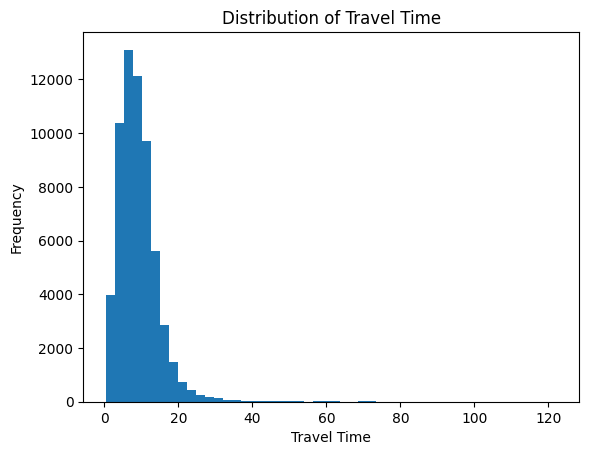

In [ ]:
#Exploratory Data Analysis
#To better understand the dataset, exploratory data analysis (EDA) is conducted
#on key traffic variables and the target variable, travel time.
#(1) Distribution of Target Variable
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/refs/heads/main/data/cleansed_traffic_monitoring.csv"
df = pd.read_csv(url)

plt.hist(df['Travel_Time'], bins=50)
plt.title("Distribution of Travel Time")
plt.xlabel("Travel Time")
plt.ylabel("Frequency")
plt.show()

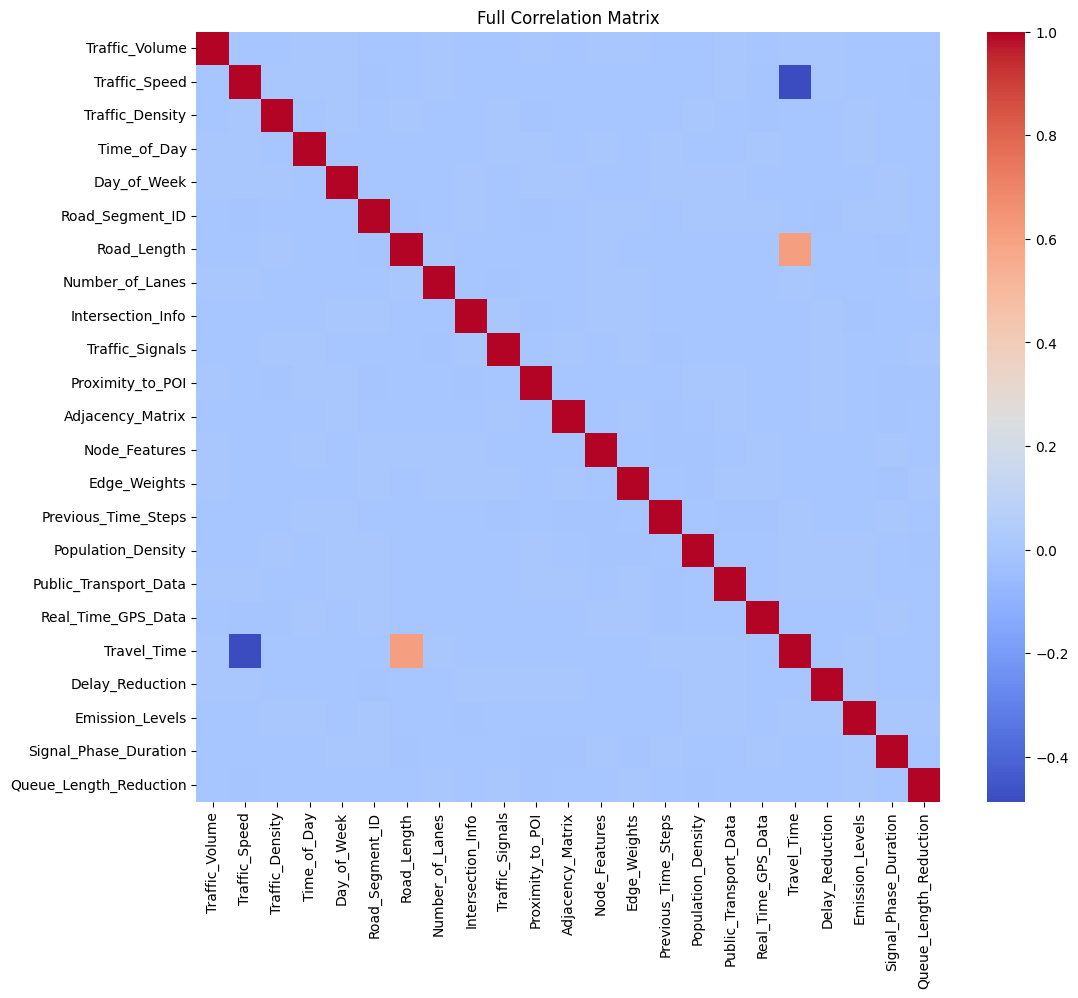

In [ ]:
import seaborn as sns

#(2) Correlation heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Full Correlation Matrix")
plt.show()

In [ ]:
#(3) Feature Importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = [
    'Traffic_Speed',
    'Road_Length',
    'Traffic_Volume',
    'Traffic_Density',
    'Signal_Phase_Duration',
    'Number_of_Lanes',
    'Time_of_Day',
    'Day_of_Week'
]

y = df['Travel_Time']
X = df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

                 Feature  Importance
0          Traffic_Speed    0.562897
1            Road_Length    0.403179
2         Traffic_Volume    0.009058
4  Signal_Phase_Duration    0.008281
6            Time_of_Day    0.006229
7            Day_of_Week    0.003842
3        Traffic_Density    0.003375
5        Number_of_Lanes    0.003139


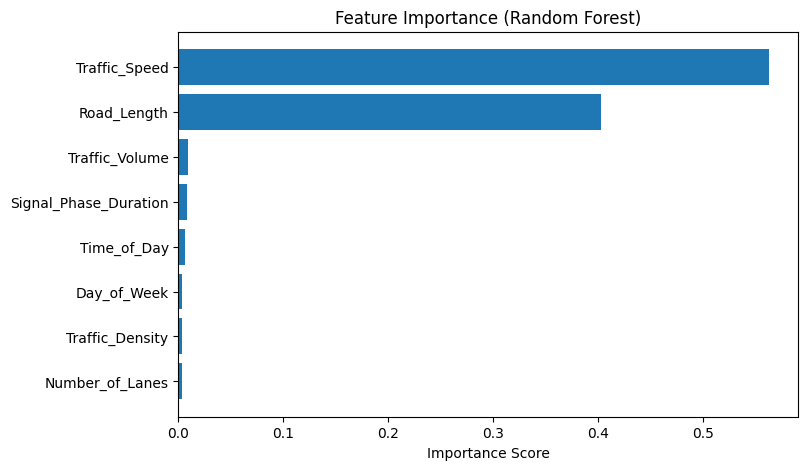

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

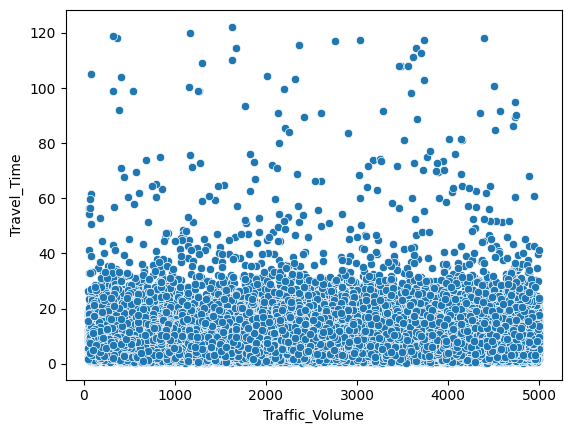

In [ ]:
#(4) Scatter Plot
sns.scatterplot(x='Traffic_Volume', y='Travel_Time', data=df)
plt.show()

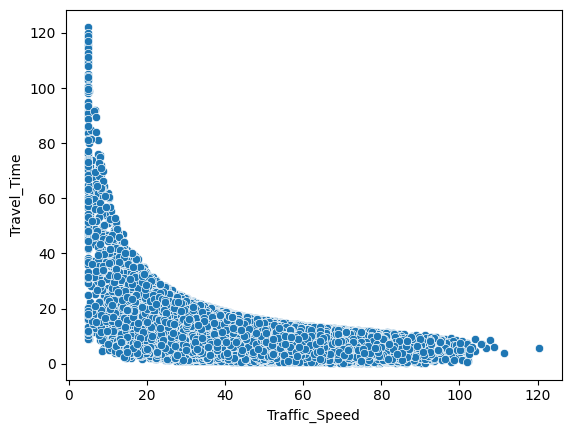

In [ ]:
sns.scatterplot(x='Traffic_Speed', y='Travel_Time', data=df)
plt.show()

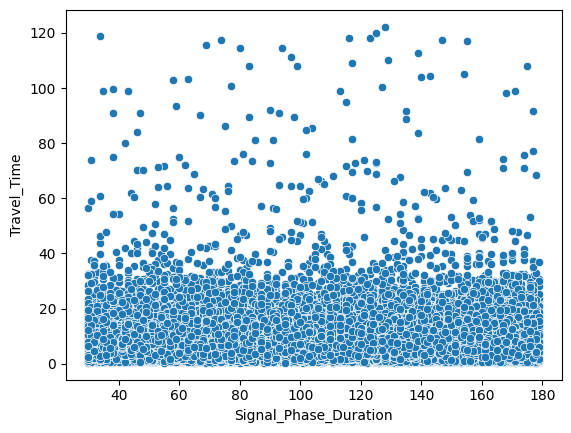

In [ ]:
sns.scatterplot(x='Signal_Phase_Duration', y='Travel_Time', data=df)
plt.show()

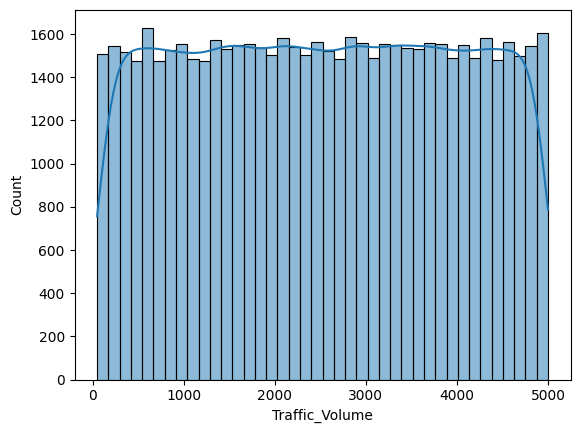

In [ ]:
#(4) Feature Distribution
sns.histplot(df['Traffic_Volume'], kde=True)
plt.show()

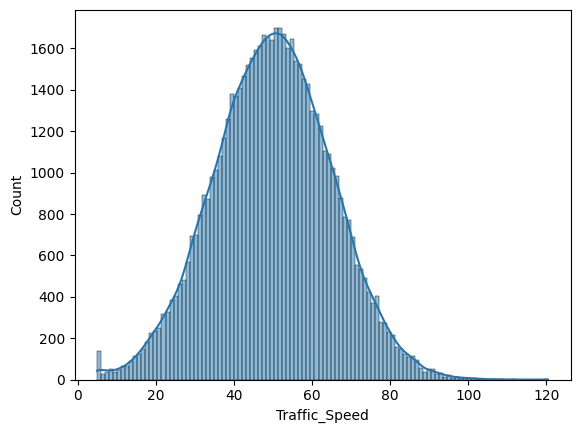

In [ ]:
sns.histplot(df['Traffic_Speed'], kde=True)
plt.show()